<a href="https://colab.research.google.com/github/RonGarcia-hub/CPE311-CPE22S3/blob/main/MIDTERM_QUIZ_2_GARCIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [9]:
IOT = pd.read_csv('RT_IOT2022.csv')

In [13]:
IOT.head()

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


##Tranform

In [16]:
IOT.dropna(inplace=True)

In [18]:
print(IOT)

          no  id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0          0      38667       1883   tcp    mqtt      32.011598             9   
1          1      51143       1883   tcp    mqtt      31.883584             9   
2          2      44761       1883   tcp    mqtt      32.124053             9   
3          3      60893       1883   tcp    mqtt      31.961063             9   
4          4      51087       1883   tcp    mqtt      31.902362             9   
...      ...        ...        ...   ...     ...            ...           ...   
123112  2005      59247      63331   tcp       -       0.000006             1   
123113  2006      59247      64623   tcp       -       0.000007             1   
123114  2007      59247      64680   tcp       -       0.000006             1   
123115  2008      59247      65000   tcp       -       0.000006             1   
123116  2009      59247      65129   tcp       -       0.000006             1   

        bwd_pkts_tot  fwd_d

In [25]:
IOT[['idle.max','idle.min']] = IOT[['idle.max','idle.min']].replace(0, '')

In [26]:
print(IOT)

          no  id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0          0      38667       1883   tcp    mqtt      32.011598             9   
1          1      51143       1883   tcp    mqtt      31.883584             9   
2          2      44761       1883   tcp    mqtt      32.124053             9   
3          3      60893       1883   tcp    mqtt      31.961063             9   
4          4      51087       1883   tcp    mqtt      31.902362             9   
...      ...        ...        ...   ...     ...            ...           ...   
123112  2005      59247      63331   tcp       -       0.000006             1   
123113  2006      59247      64623   tcp       -       0.000007             1   
123114  2007      59247      64680   tcp       -       0.000006             1   
123115  2008      59247      65000   tcp       -       0.000006             1   
123116  2009      59247      65129   tcp       -       0.000006             1   

        bwd_pkts_tot  fwd_d

##LOAD

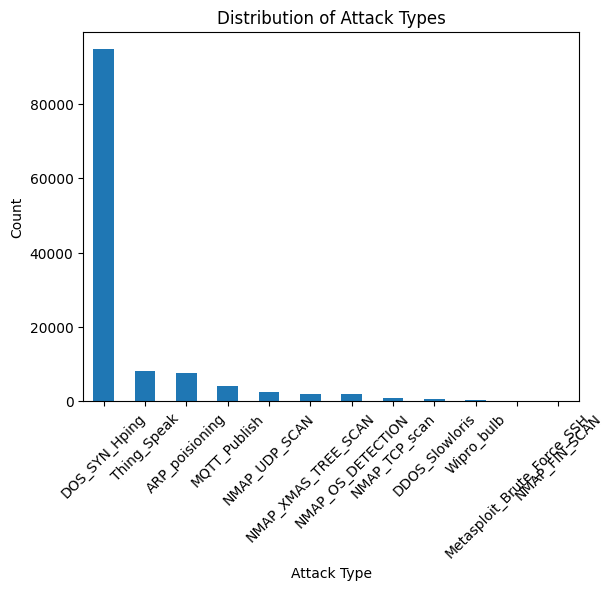

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

IOT['Attack_type'].value_counts().plot(
    kind='bar',
    title='Distribution of Attack Types'
)

plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

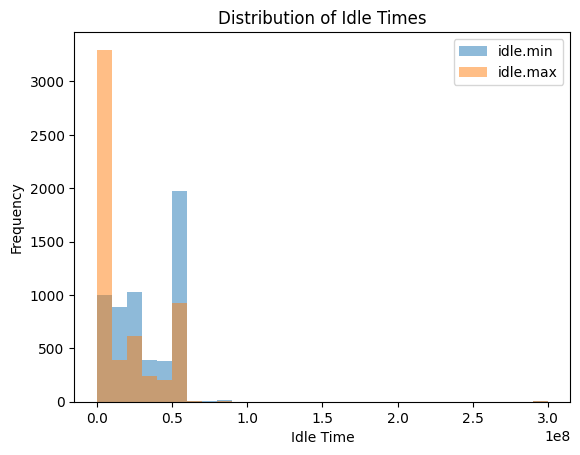

In [30]:
IOT[['idle.min','idle.max']] = IOT[['idle.min','idle.max']].apply(pd.to_numeric, errors='coerce')

IOT[['idle.min','idle.max']].plot(
    kind='hist',
    bins=30,
    alpha=0.5,
    title='Distribution of Idle Times'
)

plt.xlabel('Idle Time')
plt.show()

##ANALYSIS

From the data that we are given I have analyzed that the most frequent type of attack being the DOS_SYN_Hping which occurs well over 80k, the next would be Thing_Speak, and ARP_Poisoning. For the second visualization I decided to show the downtime or Idle time in the network and how often they occur, we can see that most idle times are small from idle.max having 0.0 dile time with a large amount of frequency, and idle.min showing a large amount on the 0.5 idle time reaching 2k frequency.